# CortexLab ZebraNoise — Quick Tour

Two-photon calcium imaging from the CortexLab, preprocessed and cached via [pixease](https://github.com/cortex-lab/pixease).

**37 sessions** across 3 mice (`BZ012`, `BZ014`, `MS019`) and 4 stimulus types:
`natural_images`, `resting_state`, `video`, `full_field_drifting_grating`.

Data directory: `D:/literatureData/CortexLab_ZebraNoise/`

In [81]:
%reload_ext autoreload
%autoreload 2

# Need the external data modules on path
import os, sys
external_path = os.getcwd()
sys.path.append(external_path)

import matplotlib.pyplot as plt
import numpy as np
from pixease_data import PixeaseRegistry
from dimilibi import make_time_splits, PCA
from rastermap import Rastermap
from tqdm import tqdm

%matplotlib inline

## Registry — discover what's available

In [2]:
reg = PixeaseRegistry()
print(reg)
reg.available()

PixeaseRegistry(35 sessions, 3 mice, 4 stimulus types)
mouse     date          expnum    stimtype                        
--------  ------------  --------  --------------------------------
BZ012     2024-11-19    9         full_field_drifting_grating     
BZ012     2024-11-20    7         full_field_drifting_grating     
BZ012     2024-11-21    7         full_field_drifting_grating     
BZ014     2025-04-02    10        full_field_drifting_grating     
MS019     2025-02-11    11        full_field_drifting_grating     
MS019     2025-02-12    8         full_field_drifting_grating     
BZ012     2024-11-19    11        natural_images                  
BZ012     2024-11-19    7         natural_images                  
BZ012     2024-11-20    6         natural_images                  
BZ012     2024-11-20    9         natural_images                  
BZ012     2024-11-21    6         natural_images                  
BZ012     2024-11-21    9         natural_images                  
BZ014  

In [3]:
# Filter by stimulus type or mouse
reg.list(stimtype="full_field_drifting_grating")

[RecordingInfo('BZ012', '2024-11-19', expnum=9, stimtype='full_field_drifting_grating'),
 RecordingInfo('BZ012', '2024-11-20', expnum=7, stimtype='full_field_drifting_grating'),
 RecordingInfo('BZ012', '2024-11-21', expnum=7, stimtype='full_field_drifting_grating'),
 RecordingInfo('BZ014', '2025-04-02', expnum=10, stimtype='full_field_drifting_grating'),
 RecordingInfo('MS019', '2025-02-11', expnum=11, stimtype='full_field_drifting_grating'),
 RecordingInfo('MS019', '2025-02-12', expnum=8, stimtype='full_field_drifting_grating')]

## Load an experiment

Data loads lazily — nothing is read from disk until you access a property or call a method.

In [4]:
exp = reg.get("MS019", "2025-02-12", 8)
print(exp)  # not loaded yet

PixeaseExperiment('MS019', '2025-02-12', expnum=8, stimtype='full_field_drifting_grating', [not loaded])


In [5]:
exp.summary()  # triggers load
print(exp)  # now loaded

Skipping ball because it is not in the cache file
=== Full field drifting gratings ===
Type: full_field_drifting_grating (2p, pipeline "full_field_drifting_gratings")
Mouse: MS019
Session: 2025-02-12 exp 8 (MS019_2025-02-12_8)
Duration: 8 repeats
Rig: b2 (1.3 zoom)
FOV: 7 x 512 x 512 (30 μm spacing)
Laser: 920nm (15% power)
Position: [1324.7, 7809.5, 4197.0]
Notes:


PixeaseExperiment('MS019', '2025-02-12', expnum=8, stimtype='full_field_drifting_grating', [loaded])


## Cell information

In [6]:
print(f"Total ROIs:        {exp.n_cells}")
print(f"Curated cells:     {exp.iscell.sum()}")
print(f"Non-cell ROIs:     {(~exp.iscell).sum()}")

positions = exp.cellinfo.cell_positions()  # (n_cells, 3) in [z, y, x] pixels
print(f"Cell positions shape: {positions.shape}")

Total ROIs:        4390
Curated cells:     3660
Non-cell ROIs:     730
Cell positions shape: (4390, 3)


## Stimulus timings

In [7]:
trials = exp.stimulus_timings()
print(trials.shape)
trials.head(10)

(336, 7)


,duration,temporal_frequency,spatial_frequency,orientation,contrast,time_start,time_stop
0,2,8,0.04,90,1,12.165,14.184
1,2,1,0.04,45,1,15.163,17.201
2,2,1,0.04,225,1,18.179,20.218
3,2,8,0.04,180,1,21.197,23.234
4,2,4,0.04,90,1,24.212,26.251
5,2,1,0.04,1,0,27.229,29.267
6,2,4,0.04,315,1,30.245,32.284
7,2,4,0.04,45,1,33.263,35.301
8,2,8,0.04,270,1,36.279,38.317
9,2,4,0.04,135,1,39.297,41.334


In [8]:
trial_intervals = list(zip(*(trials["time_start"], trials["time_stop"])))
trial_resp = exp.interval_mean(trial_intervals, "dspikes", cells=exp.iscell)
print(f"trial_resp shape: {trial_resp.shape}  # (n_trials, n_cells)")

trial_resp shape: (336, 3660)  # (n_trials, n_cells)


In [25]:
import pandas as pd

cols = ["temporal_frequency", "orientation"]
mask = trials["contrast"] != 0
df_f = trials[mask]
data_f = trial_resp[mask]

codes = [pd.factorize(df_f[c], sort=True)[0] for c in cols]
shape = [df_f[c].nunique() for c in cols] + [exp.iscell.sum()]

result = np.zeros(shape)
counts = np.zeros(shape[:-1], dtype=int)

np.add.at(result, tuple(codes), data_f)
np.add.at(counts, tuple(codes), 1)

result /= counts[..., np.newaxis]

In [40]:
result.shape
resp = np.reshape(result, (-1, result.shape[-1]))

In [66]:
# Get full data
# start, end = exp.start_end_time()
dt = 0.1
start = trials["time_start"].min()
end = trials["time_stop"].max()
spont = exp.timeseries((start, end), "dspikes", smooth=0.3, cells=exp.iscell, dt=dt).T

# Get full data for exactly same windows as in the trial_response
spont_same = []
for _start, _stop in tqdm(trial_intervals):
    spont_same.append(exp.timeseries((_start, _stop), "dspikes", smooth=0.3, cells=exp.iscell, dt=dt).T)
spont_same = np.concatenate(spont_same, axis=0)

100%|██████████| 336/336 [00:21<00:00, 15.69it/s]


In [82]:
# spks is neurons by time
# fit rastermap
model = Rastermap(n_PCs=200, n_clusters=100, locality=0.75, time_lag_window=0).fit(spont.T)
isort = model.isort

2026-04-09 12:32:58,999 [INFO] normalizing data across axis=1
2026-04-09 12:32:59,261 [INFO] projecting out mean along axis=0
2026-04-09 12:32:59,546 [INFO] data normalized, 0.55sec
2026-04-09 12:32:59,546 [INFO] sorting activity: 3660 valid samples by 10126 timepoints
2026-04-09 12:33:00,907 [INFO] n_PCs = 200 computed, 1.91sec
2026-04-09 12:33:01,401 [INFO] 100 clusters computed, time 2.40sec
2026-04-09 12:33:14,577 [INFO] clusters sorted, time 15.58sec
2026-04-09 12:33:14,749 [INFO] clusters upsampled, time 15.75sec
2026-04-09 12:33:14,912 [INFO] rastermap complete, time 15.91sec


In [83]:
# Measure how much of the spontaneous window is covered by the response intervals
spont_time = np.arange(start, end + dt, dt)  # Include an extra bin to cover the end coverage
trial_intervals = list(zip(*(trials["time_start"], trials["time_stop"])))
coverage = np.zeros_like(spont_time, dtype=bool)
for _start, _stop in trial_intervals:
    coverage |= (spont_time >= _start) & (spont_time < _stop)

print(coverage.shape, coverage.sum())

(10127,) 6853


In [87]:
spont.min(), spont.max(), resp.min(), resp.max()

(0.0, 12979.385506551958, 0.0, 1116.9906243218315)

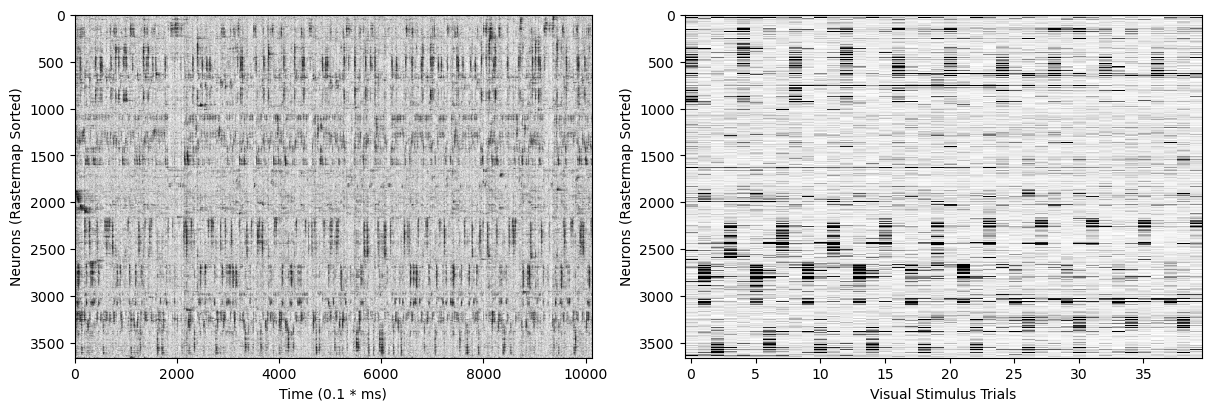

In [ ]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    layout="constrained",
)
ax[0].imshow(spont.T[isort], aspect="auto", cmap="gray_r", vmin=0, vmax=100)
ax[0].set_xlabel("Time (0.1 * ms)")
ax[0].set_ylabel("Neurons (Rastermap Sorted)")
ax[1].imshow(resp.T[isort], aspect="auto", cmap="gray_r", vmin=0, vmax=100, interpolation="none")
ax[1].set_xlabel("Visual Stimulus Trials")
ax[1].set_ylabel("Neurons (Rastermap Sorted)")
plt.show()

In [ ]:
cross_corr = np.corrcoef(spont, resp)[spont.shape[0] :, : spont.shape[0]]
isort_time = Rastermap(n_PCs=10, n_clusters=8, locality=0.75, time_lag_window=0).fit(cross_corr.T).isort
isort_stim = Rastermap(n_PCs=10, n_clusters=8, locality=0.75, time_lag_window=0).fit(cross_corr).isort

2026-04-09 12:44:17,772 [INFO] normalizing data across axis=1
2026-04-09 12:44:17,772 [INFO] projecting out mean along axis=0
2026-04-09 12:44:17,772 [INFO] data normalized, 0.00sec
2026-04-09 12:44:17,772 [INFO] sorting activity: 10126 valid samples by 40 timepoints
2026-04-09 12:44:17,804 [INFO] n_PCs = 10 computed, 0.03sec
2026-04-09 12:44:17,868 [INFO] 8 clusters computed, time 0.10sec
2026-04-09 12:44:17,868 [INFO] clusters sorted, time 0.10sec
2026-04-09 12:44:17,891 [INFO] clusters upsampled, time 0.12sec
2026-04-09 12:44:17,894 [INFO] rastermap complete, time 0.12sec
2026-04-09 12:44:17,895 [INFO] normalizing data across axis=1
2026-04-09 12:44:17,895 [INFO] projecting out mean along axis=0
2026-04-09 12:44:17,895 [INFO] data normalized, 0.00sec
2026-04-09 12:44:17,895 [INFO] sorting activity: 40 valid samples by 10126 timepoints
2026-04-09 12:44:17,920 [INFO] n_PCs = 10 computed, 0.03sec
2026-04-09 12:44:18,017 [INFO] clusters sorted, time 0.12sec
2026-04-09 12:44:18,051 [INFO

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\rastermap\rastermap.py:357: UserWarning: data has <= 50 samples, 

                                going to skip clustering and sort samples
  warnings.warn("""data has <= 50 samples, \n


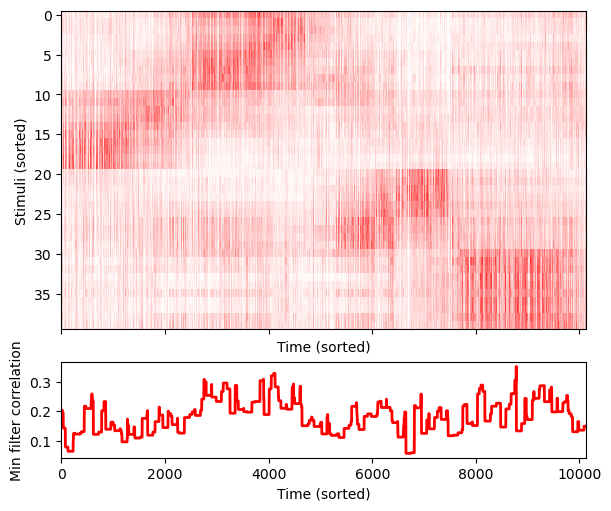

: 

In [ ]:
from scipy.ndimage import minimum_filter1d

min_cc = minimum_filter1d(np.max(cross_corr, axis=0)[isort_time], size=100, axis=0)

plt.close("all")
fig, ax = plt.subplots(2, 1, figsize=(6, 5), layout="constrained", height_ratios=[1, 0.3], sharex=True)
ax[0].imshow(cross_corr[isort_stim].T[isort_time].T, aspect="auto", cmap="bwr", vmin=-1.0, vmax=1.0, interpolation="none")
ax[0].set_xlabel("Time (sorted)")
ax[0].set_ylabel("Stimuli (sorted)")
ax[1].plot(min_cc, color="red", linewidth=2)
ax[1].set_xlabel("Time (sorted)")
ax[1].set_ylabel("Min filter correlation")
plt.show()

In [67]:
resp.shape, spont.shape, spont_same.shape

((40, 3660), (10126, 3660), (7056, 3660))

In [71]:
stim_var = np.var(resp, axis=0)

# Filter by neurons so cov is manageable
idx_keep = stim_var > 1.0
resp_keep = resp[:, idx_keep]
spont_keep = spont[:, idx_keep]
spont_same_keep = spont_same[:, idx_keep]

print(resp_keep.shape, spont_keep.shape, spont_same_keep.shape)

(40, 3660) (10126, 3660) (7056, 3660)


In [75]:
# Cross-validate spontaneous covariance
n_frames = spont_keep.shape[0]
time_splits = make_time_splits(n_frames, num_groups=2, relative_size=None, chunks_per_group=8, num_buffer=5, force_even=False)
time_splits_same = make_time_splits(spont_same_keep.shape[0], num_groups=2, relative_size=None, chunks_per_group=8, num_buffer=5, force_even=False)
spont_train = spont_keep[time_splits[0].numpy()]
spont_test = spont_keep[time_splits[1].numpy()]
spont_same_train = spont_same_keep[time_splits_same[0].numpy()]
spont_same_test = spont_same_keep[time_splits_same[1].numpy()]

# Measure training covariance with PCA to make root-cov easy
num_components_train = min(*resp_keep.shape, *spont_train.shape, *spont_same_train.shape)
pca_stim = PCA(num_components=num_components_train, center=True).fit(resp_keep.T)
pca_spont_train = PCA(num_components=num_components_train, center=True).fit(spont_train.T)
pca_spont_same_train = PCA(num_components=num_components_train, center=True).fit(spont_same_train.T)

train_evecs_stim = pca_stim.get_components().numpy()
train_eval_stim_root = np.diag(np.sqrt(pca_stim.get_eigenvalues().numpy()))
train_evecs_spont = pca_spont_train.get_components().numpy()
train_eval_spont_root = np.diag(np.sqrt(pca_spont_train.get_eigenvalues().numpy()))
train_evecs_spont_same = pca_spont_same_train.get_components().numpy()
train_eval_spont_same_root = np.diag(np.sqrt(pca_spont_same_train.get_eigenvalues().numpy()))

# Measure cross-covariance with test data (stim-spont, spont-spont)
C_spont_test = np.cov(spont_test, rowvar=False)
C_spont_same_test = np.cov(spont_same_test, rowvar=False)
inner_block_stim = train_eval_stim_root @ train_evecs_stim.T @ C_spont_test @ train_evecs_stim @ train_eval_stim_root
inner_block_spont = train_eval_spont_root @ train_evecs_spont.T @ C_spont_test @ train_evecs_spont @ train_eval_spont_root

inner_block_stim_same = train_eval_stim_root @ train_evecs_stim.T @ C_spont_same_test @ train_evecs_stim @ train_eval_stim_root
inner_block_spont_same = (
    train_eval_spont_same_root @ train_evecs_spont_same.T @ C_spont_same_test @ train_evecs_spont_same @ train_eval_spont_same_root
)

variance_stim = np.sqrt(np.maximum(np.flipud(np.linalg.eigvalsh(inner_block_stim)), 0.0))
variance_spont = np.sqrt(np.maximum(np.flipud(np.linalg.eigvalsh(inner_block_spont)), 0.0))
variance_stim_same = np.sqrt(np.maximum(np.flipud(np.linalg.eigvalsh(inner_block_stim_same)), 0.0))
variance_spont_same = np.sqrt(np.maximum(np.flipud(np.linalg.eigvalsh(inner_block_spont_same)), 0.0))

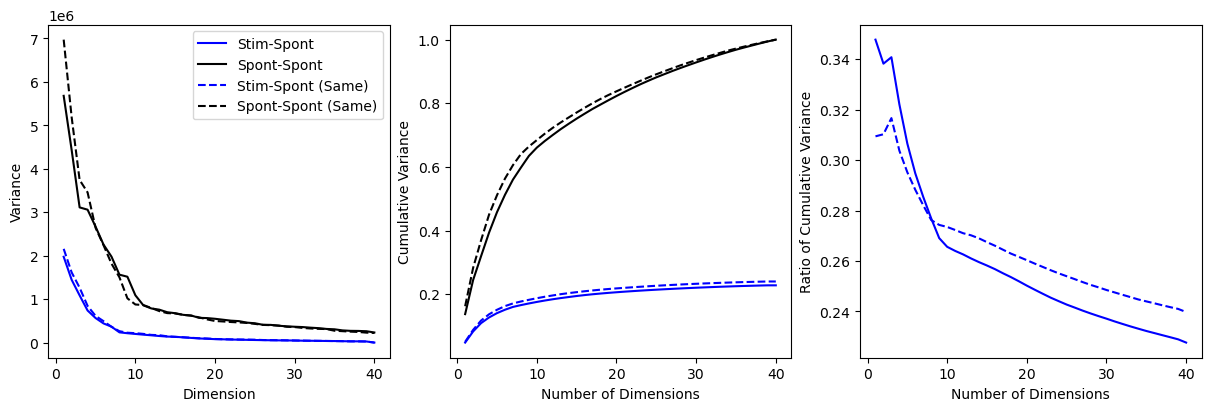

In [ ]:
xvals = lambda x: range(1, len(x) + 1)
norm = lambda x: x / np.sum(x)
total_spont = np.nansum(variance_spont)
total_spont_same = np.nansum(variance_spont_same)

offsets = 0.00
plt.close("all")
fig, ax = plt.subplots(1, 3, figsize=(12, 4), layout="constrained", width_ratios=[1, 1, 1])
ax[0].plot(xvals(variance_stim), variance_stim, label="Stim-Spont", color="Blue")
ax[0].plot(xvals(variance_spont), variance_spont, label="Spont-Spont", color="Black")
ax[0].plot(xvals(variance_stim_same), variance_stim_same, label="Stim-Spont (Same)", color="Blue", linestyle="dashed")
ax[0].plot(xvals(variance_spont_same), variance_spont_same, label="Spont-Spont (Same)", color="Black", linestyle="dashed")
ax[0].legend()
ax[0].set_xlabel("Dimension")
ax[0].set_ylabel("Variance")

cumulative_stim = np.cumsum(variance_stim) / total_spont
cumulative_spont = np.cumsum(variance_spont) / total_spont
cumulative_stim_same = np.cumsum(variance_stim_same) / total_spont_same
cumulative_spont_same = np.cumsum(variance_spont_same) / total_spont_same
ax[1].plot(xvals(cumulative_stim), cumulative_stim, label="Stim-Stim", color="Blue")
ax[1].plot(xvals(cumulative_spont), cumulative_spont, label="Spont-Spont", color="Black")
ax[1].plot(xvals(cumulative_stim_same), cumulative_stim_same, label="Stim-Spont (Same)", color="Blue", linestyle="dashed")
ax[1].plot(xvals(cumulative_spont_same), cumulative_spont_same, label="Spont-Spont (Same)", color="Black", linestyle="dashed")
ax[1].set_xlabel("Number of Dimensions")
ax[1].set_ylabel("Cumulative Variance")

ratio = cumulative_stim / cumulative_spont
ratio_same = cumulative_stim_same / cumulative_spont_same
ax[2].plot(xvals(cumulative_stim), ratio, label="Stim-Spont", color="Blue")
ax[2].plot(xvals(cumulative_stim_same), ratio_same, label="Stim-Spont (Same)", color="Blue", linestyle="dashed")
ax[2].set_xlabel("Number of Dimensions")
ax[2].set_ylabel("Ratio of Cumulative Variance")
plt.show()